# Project Milestone One: Form Your Team, Understand the Problem, and Explore the Data

#### **Due:** July 12th @ 11:59 PM (with a 2 hour & 1 minute grace period)

#### **Important:** There is **no late period** for this assignment, as manual grading must begin immediately after the deadline.

## What You Will Do in This Milestone

1. Form your project team and complete the **Team Contract** (available in the Homework Repository). Submit one copy to Gradescope.
2. Select a **team leader**, who will submit this notebook on behalf of the team after everyone has contributed to the assignment. This <a href=https://guides.gradescope.com/hc/en-us/articles/21863861823373-Adding-Group-Members-to-a-Submission>Gradescope guide</a> explains how to add group members to a submission.
3. After completing this milestone, **each team member** must complete an **Individual Team Evaluation** (available in the Homework Repository) and submit it individually to Gradescope.
4. Complete a simplified version of the **Machine Learning Project Checklist** from Appendix A of *Hands-On Machine Learning* (p. 779):

> **Part 1:** Frame the problem and understand the project goals   
> **Part 2:** Explore and understand the dataset   
> **Part 3:** Clean and prepare the data   
> **Part 4:** Investigate feature relationships   
> **Part 5:** Develop hypotheses for feature engineering and preprocessing

## The Dataset

All teams will work with the same dataset: a reduced version of the Zillow housing dataset used in the **Zillow Prize** competition on Kaggle in 2017 (unfortunately, the competition has long since ended!).

Your goal is to predict a property's **assessed tax value** (`taxvaluedollarcnt`) from a large collection of property characteristics. The dataset contains many of the challenges encountered in real machine learning projects, including:

* Missing values
* Potential outliers
* Redundant and highly correlated features
* Identifier variables that may not be useful for prediction
* Features that require careful interpretation before preprocessing

Unlike many educational datasets, this one has **not** been extensively preprocessed. Throughout this milestone, your objective is to understand the data, identify potential issues, and develop hypotheses about preprocessing and feature engineering. In **Milestone 2**, you will evaluate many of these ideas experimentally to determine whether they actually improve model performance.



In [1]:
# =============================
# Useful Imports
# =============================

# Standard Libraries
import os
import time
import math
import io
import zipfile
import requests
from urllib.parse import urlparse
from itertools import chain, combinations

# Data Science Libraries
import numpy as np
import pandas as pd
import seaborn as sns

# Visualization
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import matplotlib.ticker as mticker  # Optional: Format y-axis labels as dollars

# Scikit-learn (Machine Learning)
from sklearn.model_selection import (
    train_test_split, 
    cross_val_score, 
    GridSearchCV, 
    RandomizedSearchCV, 
    RepeatedKFold
)
from sklearn.preprocessing import StandardScaler, OrdinalEncoder
from sklearn.impute import SimpleImputer
from sklearn.metrics import mean_squared_error
from sklearn.feature_selection import SequentialFeatureSelector, f_regression, SelectKBest
from sklearn.datasets import make_regression
from sklearn.ensemble import BaggingRegressor, RandomForestRegressor, GradientBoostingRegressor

# Kaggle and Progress Tracking
from tqdm import tqdm

# =============================
# Global Variables
# =============================
random_state = 42

# =============================
# Utility Functions
# =============================

# Format y-axis labels as dollars with commas (optional)
def dollar_format(x, pos):
    return f'${x:,.0f}'

# Convert seconds to HH:MM:SS format
def format_hms(seconds):
    return time.strftime("%H:%M:%S", time.gmtime(seconds))



## Prelude: Download the Zillow Housing Dataset 

The code cell below will load the dataset for you.    

> **Notice that before downloading, this cell first checks whether the files already exist.** 

For a detailed description of the dataset features, please refer to  **Appendix 1** below. 


In [2]:

url = "https://www.cs.bu.edu/fac/snyder/cs505/Data/zillow_dataset.csv"

filename = os.path.basename(urlparse(url).path)

if not os.path.exists(filename):
    try:
        print("Downloading the file...")
        response = requests.get(url)
        response.raise_for_status()  # Raise an error for bad status codes
        with open(filename, "wb") as f:
            f.write(response.content)
        print("File downloaded successfully.")
    except requests.exceptions.RequestException as e:
        print(f"Error downloading the file: {e}")
else:
    print("File already exists. Skipping download.")

df = pd.read_csv(filename)

File downloaded successfully.


## Part 1: Frame the problem and look at the big picture [3 pts]

This part is a bit vague, since this project is not taking place in an actual business, but for the sake of exercising all the steps, **pretend** that you are working at Zillow as a data analyst and are given this dataset and asked to
- Analyze and understand the data; 
- Develop a regression model;
- Give a presentation to the marketing team about your results.  

#### **1 Discussion:** 

AFTER doing your EDA, come back and answer each of the following 3 questions in a *concise and informative paragraph between the lines;* you may wish to use your own business or home-buying experience, or to do some online research about the issues before you propose your ideas. (Don't stress about this, but *humor your professor and give it your best shot!*)


**1.1:**  What is the objective of this project in business terms?

Zillow relies on timely, accurate estimates of a property's value to power the products and services that make it money: consumer-facing valuation tools (like the Zestimate), lead generation for real estate agents, and, at the time this dataset was collected, its Zillow Offers home-buying business. The specific column we are predicting, `taxvaluedollarcnt`, is the county assessor's estimate of a property's total assessed value, which is closely related to (but not identical to) market value. The business objective of this project is to build a regression model that predicts this assessed value directly from property characteristics such as size, location, age, and amenities, so that Zillow can generate a value estimate for a property automatically and at scale, rather than depending purely on county assessments (which can be infrequent, inconsistent across counties, and slow to reflect market changes) or expensive manual appraisals. In short, the project turns a labor-intensive, manual valuation problem into an automated, data-driven one that can be applied consistently across millions of properties.


**1.2:**  How will your solution be used?

The model's predictions would feed into several downstream, decision-support workflows rather than being used as a fully autonomous financial decision. Internally, the predicted value could be compared against a property's actual assessed value (or a recent sale price, if available) to flag properties that appear over- or under-assessed, which is useful both for Zillow's own analytics and potentially for consumers appealing their property taxes. The predictions could also be surfaced on consumer-facing property pages as an estimated value, similar to a Zestimate, to help buyers, sellers, and agents gauge a fair price range. A pricing or investment team could use the model as one input (alongside other signals) when deciding which properties to target for offers or marketing campaigns. Finally, since the assignment asks us to present results to a marketing team, the model and its outputs would also be used as a decision-support tool in that presentation, illustrating which property characteristics most strongly drive value and where the model is confident versus uncertain, rather than being deployed as the sole basis for any transaction.

**1.3:**  How should success (or failure) be measured?

On the technical side, success should be measured with standard regression metrics computed on a held-out test set, most likely RMSE (Root Mean Squared Error) and MAE (Mean Absolute Error), since these are interpretable directly in dollars and are the metrics used in the original Zillow Prize competition (which used a related log-error metric). Because `taxvaluedollarcnt` is heavily right-skewed, it may also be informative to look at percentage-based errors (like MAPE) so that a large absolute error on an expensive property isn't weighted the same as a large absolute error on an inexpensive one, and to compare the model against a simple baseline (e.g., predicting the median value, or a simple linear regression on a few features) to make sure the added complexity is actually earning its keep. Just as important is checking that errors are not systematically biased for particular subgroups, for example by county (`fips`), by property type, or by price range, since a model that is accurate on average but consistently under- or over-predicts for certain neighborhoods would be a business failure even with a good overall RMSE. In business terms, success means the predictions are close enough, and unbiased enough, to be trustworthy inputs for the downstream uses described in 1.2; failure would look like large or systematically biased errors that would mislead a homeowner, agent, or internal team relying on the estimate.

## Part 2: Download and perform preliminary exploration of the data [4 pts]

### Part 2.A: Load the data into a dataframe and study each feature/column and its characteristics:
- Feature Name
- Type (categorical, int/float, text, etc.)
- Apparent usefulness for the task
- Approximate % of missing values
- How many unique values

**Note:** The **target** is the last column `'taxvaluedollarcnt'` -- pay particular attention to this during the EDA process. 
  
Hint: Just use `.head()`, `.info()`, and `.nunique()`.

In [3]:
# Load the dataset into a DataFrame
df = pd.read_csv('zillow_dataset.csv')

# Preview the first few rows to see what the raw data looks like
df.head()

,parcelid,airconditioningtypeid,architecturalstyletypeid,basementsqft,bathroomcnt,bedroomcnt,buildingclasstypeid,buildingqualitytypeid,calculatedbathnbr,decktypeid,...,yardbuildingsqft17,yardbuildingsqft26,yearbuilt,numberofstories,fireplaceflag,assessmentyear,taxdelinquencyflag,taxdelinquencyyear,censustractandblock,taxvaluedollarcnt
0,14297519,NaN,NaN,NaN,3.5,4.0,NaN,NaN,3.5,NaN,...,NaN,NaN,1998.0,NaN,NaN,2016.0,NaN,NaN,6.059063e+13,1023282.0
1,17052889,NaN,NaN,NaN,1.0,2.0,NaN,NaN,1.0,NaN,...,NaN,NaN,1967.0,1.0,NaN,2016.0,NaN,NaN,6.111001e+13,464000.0
2,14186244,NaN,NaN,NaN,2.0,3.0,NaN,NaN,2.0,NaN,...,NaN,NaN,1962.0,1.0,NaN,2016.0,NaN,NaN,6.059022e+13,564778.0
3,12177905,NaN,NaN,NaN,3.0,4.0,NaN,8.0,3.0,NaN,...,NaN,NaN,1970.0,NaN,NaN,2016.0,NaN,NaN,6.037300e+13,145143.0
4,10887214,1.0,NaN,NaN,3.0,3.0,NaN,8.0,3.0,NaN,...,NaN,NaN,1964.0,NaN,NaN,2016.0,NaN,NaN,6.037124e+13,119407.0


In [4]:
# Structure of the DataFrame: column names, dtypes, and non-null counts
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 77613 entries, 0 to 77612
Data columns (total 55 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   parcelid                      77613 non-null  int64  
 1   airconditioningtypeid         25007 non-null  float64
 2   architecturalstyletypeid      207 non-null    float64
 3   basementsqft                  50 non-null     float64
 4   bathroomcnt                   77579 non-null  float64
 5   bedroomcnt                    77579 non-null  float64
 6   buildingclasstypeid           15 non-null     float64
 7   buildingqualitytypeid         49809 non-null  float64
 8   calculatedbathnbr             76963 non-null  float64
 9   decktypeid                    614 non-null    float64
 10  finishedfloor1squarefeet      6037 non-null   float64
 11  calculatedfinishedsquarefeet  77378 non-null  float64
 12  finishedsquarefeet12          73923 non-null  float64
 13  finishedsqua

In [5]:
# Number of unique values per column
df.nunique()

parcelid                        77414
airconditioningtypeid               5
architecturalstyletypeid            5
basementsqft                       43
bathroomcnt                        22
bedroomcnt                         16
buildingclasstypeid                 2
buildingqualitytypeid              12
calculatedbathnbr                  21
decktypeid                          1
finishedfloor1squarefeet         1787
calculatedfinishedsquarefeet     4972
finishedsquarefeet12             4868
finishedsquarefeet13               13
finishedsquarefeet15             1724
finishedsquarefeet50             1807
finishedsquarefeet6               350
fips                                3
fireplacecnt                        5
fullbathcnt                        13
garagecarcnt                       14
garagetotalsqft                   839
hashottuborspa                      1
heatingorsystemtypeid              10
latitude                        64038
longitude                       62461
lotsizesquar

In [6]:
# Build a single summary table combining dtype, % missing, and # unique values
# for every feature, to make it easier to scan all characteristics at once.
summary = pd.DataFrame({
    'dtype': df.dtypes,
    'pct_missing': (df.isna().mean() * 100).round(2),
    'n_unique': df.nunique()
})
summary

,dtype,pct_missing,n_unique
parcelid,int64,0.00,77414
airconditioningtypeid,float64,67.78,5
architecturalstyletypeid,float64,99.73,5
basementsqft,float64,99.94,43
bathroomcnt,float64,0.04,22
bedroomcnt,float64,0.04,16
buildingclasstypeid,float64,99.98,2
buildingqualitytypeid,float64,35.82,12
calculatedbathnbr,float64,0.84,21
decktypeid,float64,99.21,1


#### **2.A Discussion:** 

Answer the following questions. You may wish to examine Appendix 3 before starting. 

**2.A.1:**  Which features are categorical?

Even though most of the "type" columns are stored as floats or ints, they represent codes for categories rather than measurable quantities, so they are categorical. Based on Appendix 1 and the flowchart in Appendix 3, we identified the following as categorical features: `airconditioningtypeid`, `architecturalstyletypeid`, `buildingclasstypeid`, `buildingqualitytypeid` (ordinal), `decktypeid`, `fips`, `heatingorsystemtypeid`, `pooltypeid10`, `pooltypeid2`, `pooltypeid7`, `propertycountylandusecode`, `propertylandusetypeid`, `propertyzoningdesc`, `regionidcity`, `regionidcounty`, `regionidneighborhood`, `regionidzip`, `storytypeid`, and `typeconstructiontypeid`. In addition, `hashottuborspa`, `fireplaceflag`, and `taxdelinquencyflag` are binary/boolean categorical flags stored as object/boolean columns. Geographic identifiers like `rawcensustractandblock` and `censustractandblock` are also more like categorical/identifier codes than continuous measurements, even though they look numeric.

**2.A.2:**  Are there any features which appear at first glance to be **useless** for the business purpose of this project and should be deleted?  Give examples and describe your reasoning briefly. 

Yes. `parcelid` is a unique identifier assigned to each property; it carries no information about a property's characteristics or value and would only encourage the model to memorize individual rows, so it should be dropped as a predictor. `assessmentyear` takes on exactly one value (2016) for every single row in the dataset, so it has zero variance and cannot possibly help distinguish one property from another. `rawcensustractandblock` and `censustractandblock` both encode nearly the same census tract/block geography and largely duplicate the information already captured by `latitude`, `longitude`, and the `regionid*` columns, so keeping both (or even one, given the other geographic columns) adds redundancy without new business signal. These are conceptually useless regardless of how much data is missing or how many unique values they have; they simply don't describe anything about the property that would plausibly relate to its assessed value.

**2.A.3:**  Are there any features which appear to be **useless** because of the percentage of missing values?  If so, give an example. 

Yes, several features are missing for the overwhelming majority of properties, which makes it very unlikely that imputing them would add reliable signal. For example, `buildingclasstypeid` is missing for almost 100% of rows, `storytypeid` and `basementsqft` are each missing for close to 100%, and `architecturalstyletypeid` just under 100%, `typeconstructiontypeid` also just under 100%, `fireplaceflag` just less than 100%, `taxdelinquencyflag`/`taxdelinquencyyear` just under 100%, `hashottuborspa` just less than 100%, and `poolsizesum` just less than 100% are all missing for nearly every row. So these are strong candidates for removal in Part 3.B rather than imputation.

**2.A.4:**  Are there any features which appear to be **useless** because of the number of unique values?  If so, give an example.

Yes, in two different ways. At one extreme, several columns have only 1-2 unique non-null values, meaning they carry almost no discriminating information even where they are present; examples include `storytypeid`, `decktypeid`, `pooltypeid10`, `pooltypeid2`, `poolcnt`, and `fireplaceflag`, all of which take on a single value (e.g., `True` or a single type code) whenever they are not null, essentially functioning as rare flags rather than informative features. At the other extreme, some columns are almost as granular as an identifier: `latitude` and `longitude` have roughly 64,000 and 62,000 unique values respectively (nearly one per property), and `rawcensustractandblock`/`censustractandblock` have around 39,000 unique values each. These aren't "useless" in the same way as `parcelid`, since geography clearly matters for property value, but at this level of granularity they behave more like identifiers than like features a model can generalize from directly; they would likely need to be grouped, binned, or used differently (e.g., as coordinates or joined to a coarser region) rather than used as raw categorical codes.

### Part 2.B: Exploratory Data Analysis (EDA) -- Feature-Level Visualization  

- To get an overview, generate histograms for all features using `df.hist()`  (Hint: increase the figsize and set the layout to `(-1,m)` to get  `m` columns and as many rows as necessary.)
- Generate individual visualizations for the target and three (3) additional features that you believe are particularly informative or interesting (a total of four features): 
    - Use appropriate plot types (e.g., histograms and boxplots for numerical features, bar plots for categorical features) to understand distributions and identify potential outliers for these three.
    - Use as many code cells as you need, and give comments describing what each cell does.
    - Answer the discussion question posed (you should choose 3 features for which you can say something interesting in the discussion).  

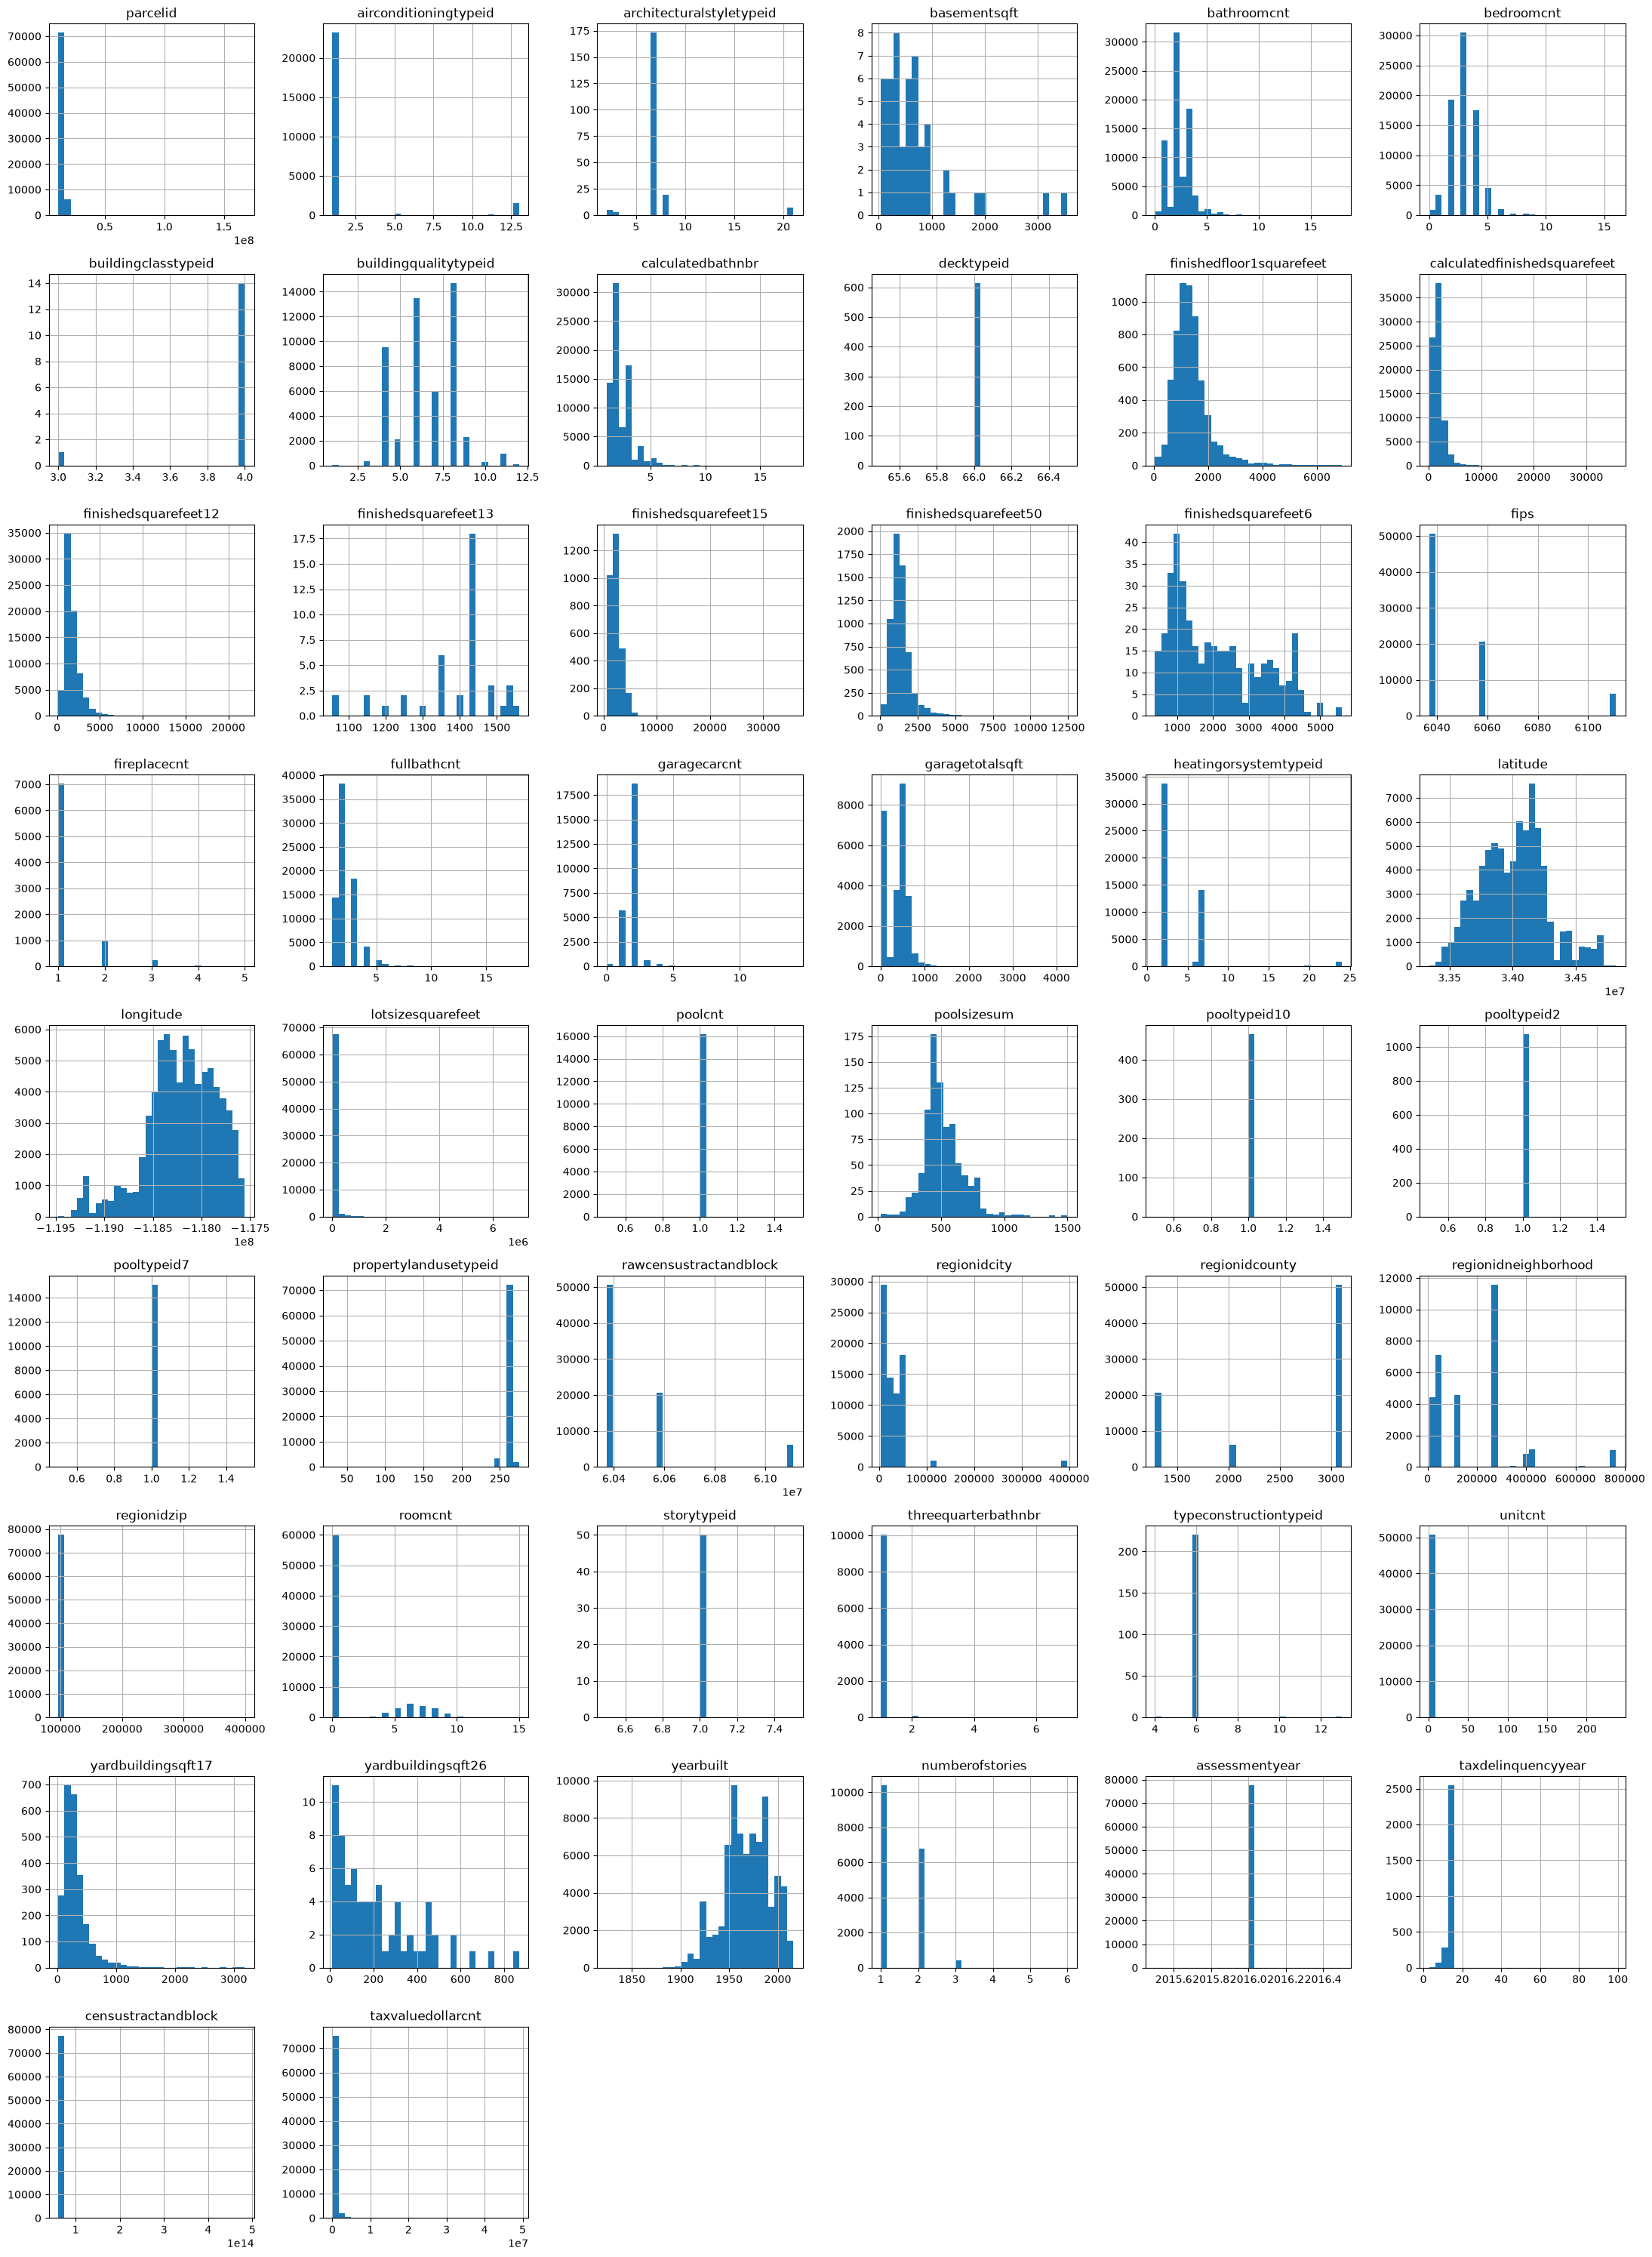

In [7]:
# Overview of every numeric feature's distribution using df.hist().
df.hist(figsize=(22, 30), layout=(-1, 6), bins=30)
plt.tight_layout()
plt.show()

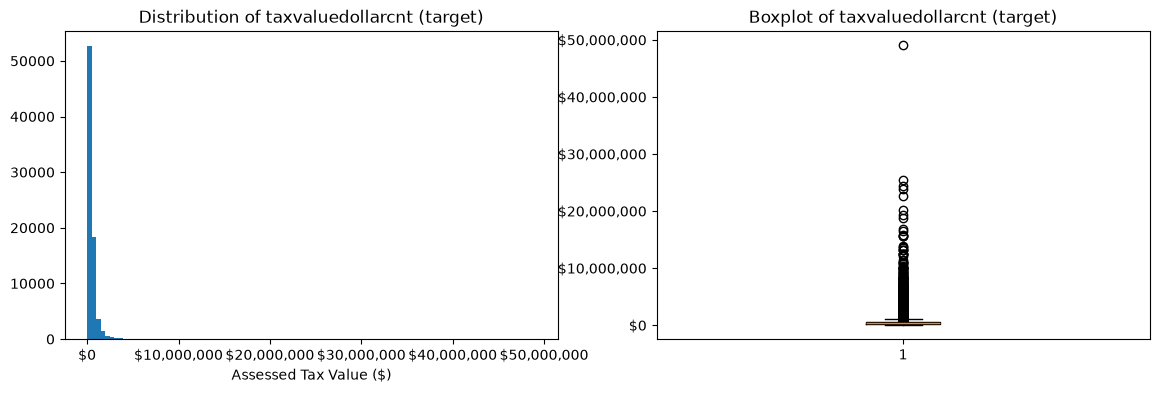

In [9]:
# Feature 1: taxvaluedollarcnt (the TARGET)
# Histogram + boxplot to examine the distribution and look for outliers.
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].hist(df['taxvaluedollarcnt'].dropna(), bins=100)
axes[0].set_title('Distribution of taxvaluedollarcnt (target)')
axes[0].set_xlabel('Assessed Tax Value ($)')
axes[0].xaxis.set_major_formatter(mticker.FuncFormatter(dollar_format))

axes[1].boxplot(df['taxvaluedollarcnt'].dropna(), orientation='vertical')
axes[1].set_title('Boxplot of taxvaluedollarcnt (target)')
axes[1].yaxis.set_major_formatter(mticker.FuncFormatter(dollar_format))

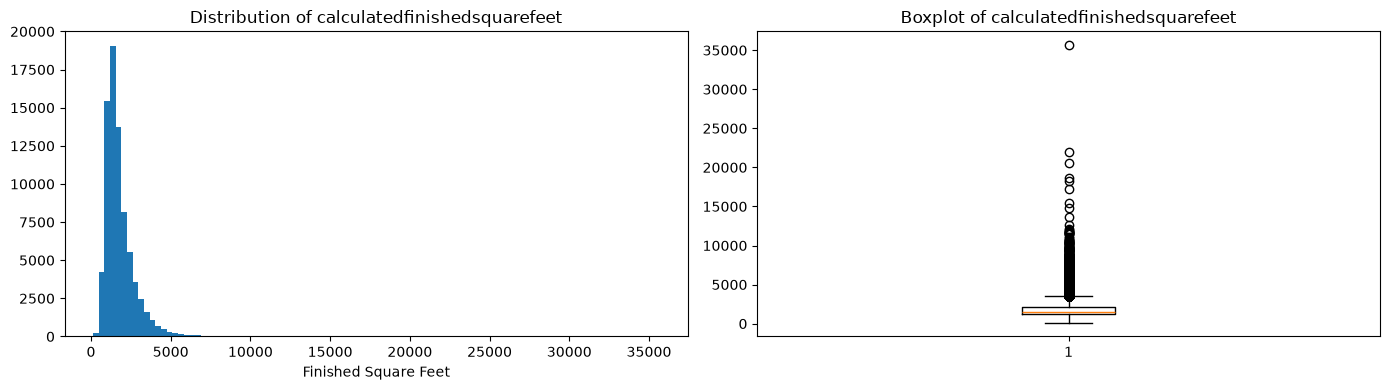

count    77378.000000
mean      1784.935421
std        954.250373
min        128.000000
25%       1182.000000
50%       1542.000000
75%       2112.000000
max      35640.000000
Name: calculatedfinishedsquarefeet, dtype: float64

In [10]:
# Feature 2: calculatedfinishedsquarefeet
# Histogram + boxplot for this numerical measure of home size.
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].hist(df['calculatedfinishedsquarefeet'].dropna(), bins=100)
axes[0].set_title('Distribution of calculatedfinishedsquarefeet')
axes[0].set_xlabel('Finished Square Feet')

axes[1].boxplot(df['calculatedfinishedsquarefeet'].dropna(), orientation='vertical')
axes[1].set_title('Boxplot of calculatedfinishedsquarefeet')

plt.tight_layout()
plt.show()

df['calculatedfinishedsquarefeet'].describe()

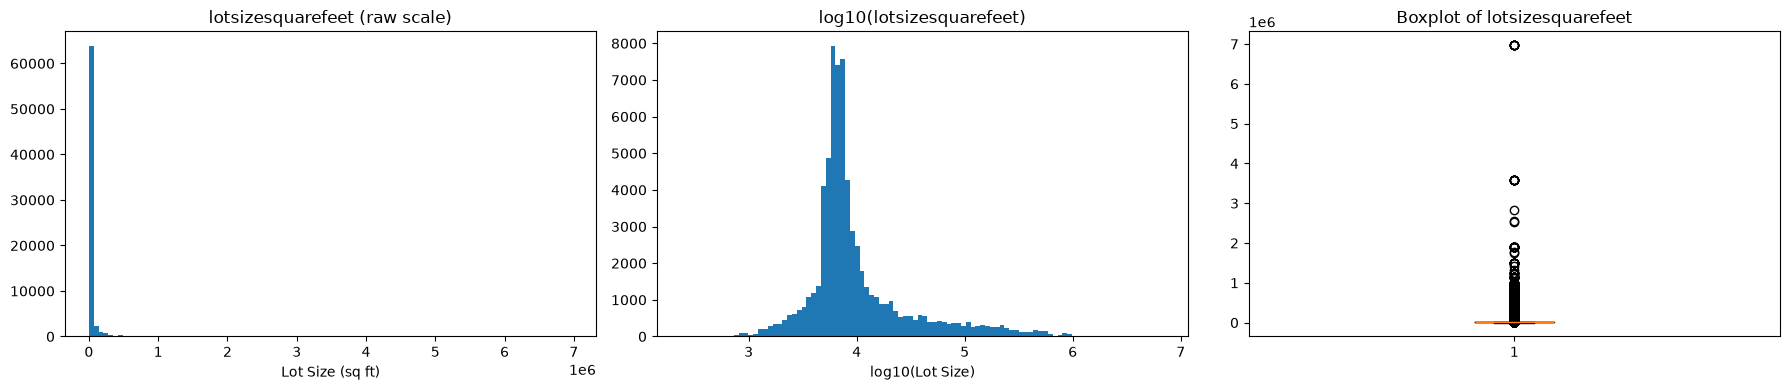

count    6.932100e+04
mean     2.997344e+04
std      1.233050e+05
min      2.360000e+02
25%      5.700000e+03
50%      7.206000e+03
75%      1.183700e+04
max      6.971010e+06
Name: lotsizesquarefeet, dtype: float64

In [12]:
# Feature 3: lotsizesquarefeet
# This feature turns out to be extremely skewed, so we look at it on both
# a normal and a log scale to see the shape more clearly, plus a boxplot.
fig, axes = plt.subplots(1, 3, figsize=(18, 4))

axes[0].hist(df['lotsizesquarefeet'].dropna(), bins=100)
axes[0].set_title('lotsizesquarefeet (raw scale)')
axes[0].set_xlabel('Lot Size (sq ft)')

axes[1].hist(np.log10(df['lotsizesquarefeet'].dropna()), bins=100)
axes[1].set_title('log10(lotsizesquarefeet)')
axes[1].set_xlabel('log10(Lot Size)')

axes[2].boxplot(df['lotsizesquarefeet'].dropna(), orientation='vertical')
axes[2].set_title('Boxplot of lotsizesquarefeet')

plt.tight_layout()
plt.show()

df['lotsizesquarefeet'].describe()

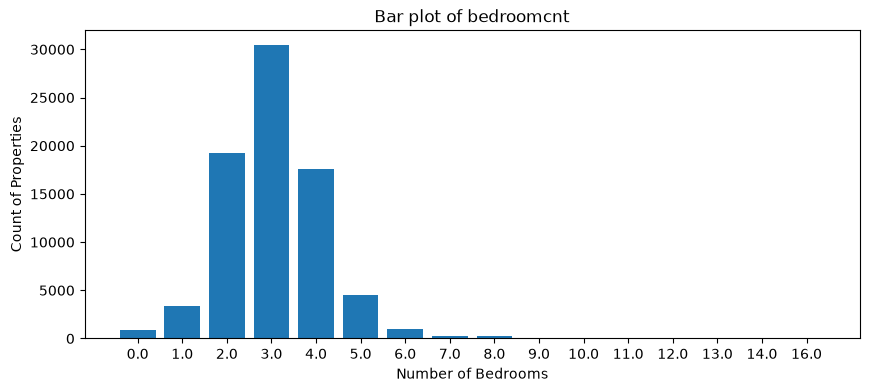

count    77579.000000
mean         3.053223
std          1.140480
min          0.000000
25%          2.000000
50%          3.000000
75%          4.000000
max         16.000000
Name: bedroomcnt, dtype: float64

In [13]:
# Feature 4: bedroomcnt
# This is a discrete count that behaves almost like a categorical feature,
# so a bar plot of value counts is more informative than a plain histogram.
counts = df['bedroomcnt'].value_counts().sort_index()

plt.figure(figsize=(10, 4))
plt.bar(counts.index.astype(str), counts.values)
plt.title('Bar plot of bedroomcnt')
plt.xlabel('Number of Bedrooms')
plt.ylabel('Count of Properties')
plt.show()

df['bedroomcnt'].describe()

#### **2.B Discussion:** 

Describe what you learned from your detailed examination of the four features you selected. For each feature, discuss:

- The overall distribution (for example, approximately normal, skewed, or multimodal).
- Any notable characteristics, such as outliers, unusual values, or missing data.
- Why you selected the feature and what you learned about the dataset from examining it.

Conclude by briefly discussing whether any of the features you examined might require additional preprocessing later in the project (such as imputation, transformation, or outlier investigation).

**taxvaluedollarcnt (target).** Heavily right-skewed (median ~$359K, max ~$49M), with a small number of very high-value outliers stretching the distribution. Missing values are negligible.

**calculatedfinishedsquarefeet.** Also right-skewed but less extreme, with most homes in the 1,200–2,100 sq ft range and a few unusually large outliers. Selected because home size is an intuitive predictor of value, and it shows a similar skew pattern to the target.

**lotsizesquarefeet.** The most skewed feature by far, with a max lot size (~7M sq ft) that repeats identically across rows — a strong sign of a data quality issue rather than a real lot size. About 10.7% missing.

**bedroomcnt.** A discrete count feature, roughly bell-shaped and centered at 3 bedrooms. Mostly well-behaved, but includes some questionable values (837 properties with 0 bedrooms).

**Conclusion.** Three of the four features (the target, `calculatedfinishedsquarefeet`, and especially `lotsizesquarefeet`) are strongly right-skewed with high-value outliers, so all three are good candidates for a log transformation before modeling, and `lotsizesquarefeet` in particular needs a closer look at its repeated extreme values to decide whether they should be treated as outliers, corrected, or dropped. `bedroomcnt` is comparatively well-behaved, but its 0-bedroom entries deserve a domain-informed decision (are they legitimate, or should they be treated as missing/imputed?). None of the four have severe missingness, so for these particular features the main preprocessing task in Part 3 is less about imputation and more about transformation and outlier handling.

## Part 3:  Clean the Data: Drop, Impute, and Encode [6 pts]



**Important Notes:**
- You should review your Homework 4 before doing this section!
- Create new names for modified data at each stage to avoid problems with global variables.
- Whenever possible, write functions for all data transformations you apply, for these reasons:
    - So you can easily prepare the data the next time you get a fresh dataset
    - So you can apply these transformations in future projects
    - To clean and prepare new data instances once your solution is live
    - To make it easy to treat your preparation choices as hyperparameters
    - [To apply the same transformations to your test set if train/test split already done -- not applicable here]

### Part 3.A: Drop features you judge to be unsuitable for the regression task

Your call, based on any research you can do to understand the feature (hopefully IRL you would have a domain expert to help with this, but do your best).   

Note: Do not drop features because of too many missing values, that's the next task! 

#### **3.A Discussion:**

Describe the features you chose to remove, if any, and justify each decision. For each feature, explain:

- Why you believed it was unsuitable for predicting the target.
- Which characteristic led to your decision (for example, an identifier, irrelevant information, or another reason).
- Why your decision was based on the feature's meaning rather than the amount of missing data.

If you chose not to remove any features, explain why.

> Replace this text with your answer.

### Part 3.B: Drop **features** with "too many" null values

Your code in the next cell(s). Make a judgement call about what "too many" means and briefly describe your reasoning in the discussion.   

Note: "Too many" may depend on what the non-null values look like, be sure to investigate carefully. 

#### **3.B Discussion:**

Describe the criteria you used to decide which features had **too many** missing values to retain.

In particular, explain:

- The threshold you selected for determining when a feature should be removed.
- Why you believe this threshold was appropriate for this dataset.
- Whether you considered the usefulness of the remaining non-null values before deciding to remove a feature, and how this influenced your decision.

> Replace this text with your answer.

### Part 3.C: Remove Problematic Samples

Some samples may not be suitable for model training because they contain insufficient information or cannot be used for supervised learning.

- Remove any sample with a missing target value.
- Decide on a reasonable threshold for the maximum percentage of missing feature values in a sample, justify your choice, and remove samples exceeding that threshold.
- Investigate whether the dataset contains potential outliers, but **do not remove them yet.** Instead, describe how you identified them and explain why removing them may or may not be appropriate. Their effect on model performance will be investigated in Milestone 2.

Your code in the next cell(s). Make a judgement call about which samples should be dropped and briefly describe your reasoning in the discussion.   


#### **3.C Discussion:**

Describe your decisions about which samples were removed and why.

In particular, discuss:

- The criteria you used to identify samples that should be removed (for example, missing target values or excessive missing data).
- If you identified potential outliers, explain how you identified them and why you chose to retain them at this stage.
- The potential advantages and disadvantages of removing outliers, and why you believe this decision should be evaluated experimentally in **Milestone 2**.

> Replace this text with your answer.

### Part 3.D: Split the Dataset into Training and Test Sets

Now that the initial data cleaning is complete, split the dataset into training and test sets.

Use:

- test_size=0.20
- random_state=42

The remaining preprocessing steps should be learned **only from the training set** and then applied unchanged to the test set. This prevents information from the test set from influencing the training process ("data leakage"). 

No discussion necessary. 

### Part 3.E: Impute for the remaining missing values

Review the methods for imputation in **Appendix 2** and choose how you will impute the remainder of the missing values. Note:
- Consider whether different methods are justified for different features.
- In the next cells, apply your imputation methods to the dataset so that no null values remain after this step.
- Fit your imputation method(s) using only the training data.
- Apply the fitted imputer(s) to both the training and test sets so that no missing values remain.
- Answer the discussion question.


#### **3.E Discussion:**

Describe your overall imputation strategy.

In particular, explain:

- Which imputation method(s) you selected.
- Why each method was appropriate for the feature(s) to which it was applied.
- Whether you used different strategies for different types of features (for example, numerical versus categorical, or approximately normal versus skewed numerical features), and why.

> Replace this text with your answer.

### 3.F: Encode the Categorical Features (if any)

Refer to Appendix 3 for a summary of feature types and appropriate encoding strategies.

- Identify any categorical features that remain after your earlier preprocessing. For each feature, determine whether it is nominal or ordinal, then choose an appropriate encoding method. Use ordinal encoding only for features with a meaningful ordering, and one-hot encoding for nominal features with no natural ordering.

- Fit the encoder(s) using only the training data, then apply the fitted encoder(s) to both the training and test sets. Some teams may have very few categorical features remaining after the earlier cleaning steps.

**Note:** Many categorical features in this dataset are represented by numeric identifier codes (for example, `propertylandusetypeid`). Do not assume that a feature is numerical simply because its data type is int or float. Instead, use the feature descriptions in Appendix 1 and flowchart in Appendix 3 to determine whether the feature represents a numerical measurement or a categorical variable.

#### **3.F Discussion:**

Describe the categorical features that remained after your earlier preprocessing.

In particular, discuss:

- Which features you identified as categorical.
- Whether each feature is **nominal** or **ordinal**, and why.
- The encoding method you selected for each feature and why it was appropriate.
- At least one feature that is represented by a numeric identifier rather than text, explaining why it is still categorical and how this influenced your encoding decision.

> Replace this text with your answer.

## Part 4: Investigate Feature Relationships [6 pts]

In this part, you will investigate relationships among the features and between the features and the target. The goal is to better understand the dataset and identify opportunities for future feature engineering.

**Important:** At this stage, you should **not** commit to any changes to the dataset based on these analyses. Many preprocessing and feature engineering decisions are model-dependent and will be evaluated experimentally in **Milestone 2**.

### Part 4.A: Correlation and Feature Importance

Investigate relationships among the features and between the features and the target.

In the next cell(s):

- Compute a **correlation matrix** for the numerical features.
- Visualize the results where appropriate (for example, a heatmap and a bar chart).
- Identify features that appear to have particularly strong or weak relationships with the target.
- Identify pairs of features that appear to be highly correlated.
- Do **not** remove or transform any features based on these analyses.

#### **4.A Discussion:**

Describe the strongest relationships you observed among the features and between the features and the target.

In particular, discuss:

- Which features appeared to be the strongest predictors of the target.
- Which pairs of features appeared to be highly correlated.
- Whether the correlation matrix and the F-statistics led you to similar conclusions about the most important features. Explain your reasoning.

> Replace this text with your answer.

#### **4.A Discussion:**

Describe the strongest relationships you observed among the features and between the features and the target.

In particular, discuss:

- Which features appeared to have the strongest relationships with the target.
- Which pairs of features appeared to be highly correlated.
- Whether any relationships suggest opportunities for future feature engineering or preprocessing in Milestone 2.

> Replace this text with your answer.

#### **4.B Discussion:**

Describe what you learned from the three feature relationships you investigated.

For each pair, discuss:

- The overall pattern you observed (for example, linear, nonlinear, weak, or strong).
- What the relationship suggests about the features and their potential usefulness for predicting the target.
- Whether your observations suggest possible feature engineering or preprocessing ideas that could be investigated in **Milestone 2**.

> Replace this text with your answer.


## Part 5: Investigate Potential Feature Engineering [6 pts]

In this part, you will identify potential feature engineering and preprocessing techniques that **may** improve model performance.

The goal is to develop hypotheses based on your exploratory data analysis—not to permanently modify the dataset. In **Milestone 2**, you will evaluate these ideas experimentally and determine whether they actually improve the model.

**Important:** Do **not** permanently transform, remove, or add features in this milestone.

## Part 5.A: Identify Potential Feature Engineering Opportunities

Based on your exploratory analysis, identify **at least three (3)** feature engineering or preprocessing techniques that you believe may improve model performance.

Possible ideas include (but are not limited to):

- Log transformations
- Scaling or normalization
- Removing highly correlated features
- Polynomial features
- Interaction features
- Binning continuous variables
- Outlier removal
- Combining or aggregating existing features

You may investigate these ideas by creating visualizations or performing exploratory analyses, but **do not permanently modify the dataset**.

#### **5.A Discussion:**

Describe the three feature engineering or preprocessing ideas you identified.

For each one, explain:

- Which feature(s) it would affect.
- Why you believe it may improve model performance.
- How you would determine in **Milestone 2** whether it actually improves the model (for example, by comparing appropriate evaluation metrics on a validation or test set).

> Replace this text with your answer.

## Part 5.B: Prioritize Your Ideas

Not all feature engineering ideas are equally promising.

Based on your investigation, select the **two** ideas you believe are most likely to improve model performance.

Briefly explain why you selected these ideas over the others.

No code is required for this section.

#### **5.B Discussion:**

Suppose you had time to evaluate only **two** feature engineering or preprocessing ideas in **Milestone 2**.

For each one, explain:

- Which idea you would prioritize.
- Why you believe it is the most promising.
- What evidence from your exploratory analysis (such as feature distributions, missing values, feature relationships, or other observations) led you to this conclusion.

> Replace this text with your answer.

#### **5 Discussion:** 

Describe in a paragraph why you chose these transformations and what you observed. 


## **Appendix 1: Features of the Zillow Dataset**  

0. **parcelid**: Unique identifier for the property parcel.  
1. **airconditioningtypeid**: Identifier for the type of air conditioning installed.  
2. **architecturalstyletypeid**: Identifier for the architectural style of the property.  
3. **basementsqft**: Square footage of the basement.  
4. **bathroomcnt**: Number of bathrooms.  
5. **bedroomcnt**: Number of bedrooms.  
6. **buildingclasstypeid**: Identifier for the building framing type (e.g., wood frame, steel frame).  
7. **buildingqualitytypeid**: Numeric value indicating the quality of the building (higher values often indicate better quality).  
8. **calculatedbathnbr**: Calculated number of bathrooms, including fractional bathrooms.  
9. **decktypeid**: Identifier for the type of deck.  
10. **finishedfloor1squarefeet**: Square footage of the finished area on the first floor.  
11. **calculatedfinishedsquarefeet**: Total finished living area square footage.  
12. **finishedsquarefeet12**: Finished living area square footage.  
13. **finishedsquarefeet13**: Perimeter living area square footage.  
14. **finishedsquarefeet15**: Total area.  
15. **finishedsquarefeet50**: Square footage of the finished area on the upper floors.  
16. **finishedsquarefeet6**: Base unfinished and finished area square footage.  
17. **fips**: Federal Information Processing Standards code, uniquely identifying counties and county equivalents.  
18. **fireplacecnt**: Number of fireplaces.  
19. **fullbathcnt**: Number of full bathrooms.  
20. **garagecarcnt**: Number of cars that can fit in the garage.  
21. **garagetotalsqft**: Total square footage of the garage.  
22. **hashottuborspa**: Indicates if the property has a hot tub or spa.  
23. **heatingorsystemtypeid**: Identifier for the type of heating system.  
24. **latitude**: Latitude coordinate of the property.  
25. **longitude**: Longitude coordinate of the property.  
26. **lotsizesquarefeet**: Lot size in square feet.  
27. **poolcnt**: Number of pools on the property.  
28. **poolsizesum**: Total square footage of all pools.  
29. **pooltypeid10**: Identifier for spa or hot tub.  
30. **pooltypeid2**: Identifier for pool with spa or hot tub.  
31. **pooltypeid7**: Identifier for pool without hot tub or spa.  
32. **propertycountylandusecode**: County land use code for the property.  
33. **propertylandusetypeid**: Identifier for the property land use type.  
34. **propertyzoningdesc**: Description of the property's zoning.  
35. **rawcensustractandblock**: Unprocessed census tract and block identifier.  
36. **regionidcity**: Identifier for the city.  
37. **regionidcounty**: Identifier for the county.  
38. **regionidneighborhood**: Identifier for the neighborhood.  
39. **regionidzip**: Identifier for the ZIP code.  
40. **roomcnt**: Total number of rooms.  
41. **storytypeid**: Identifier for the type of stories in the building (e.g., basement, attic).  
42. **threequarterbathnbr**: Number of 3/4 bathrooms (typically includes a shower but no tub).  
43. **typeconstructiontypeid**: Identifier for the type of construction (e.g., frame, masonry).  
44. **unitcnt**: Number of units in the building (e.g., for multi-family properties).  
45. **yardbuildingsqft17**: Square footage of the 17th yard building (e.g., shed).  
46. **yardbuildingsqft26**: Square footage of the 26th yard building.  
47. **yearbuilt**: Year the property was built.  
48. **numberofstories**: Number of stories in the building.  
49. **fireplaceflag**: Indicates if the property has a fireplace.  
50. **assessmentyear**: Year the property was assessed.  
51. **taxdelinquencyflag**: Indicates whether the property’s taxes are delinquent. Often “Y” if taxes are past due; otherwise null/empty.  
52. **taxdelinquencyyear**: The year in which the property’s taxes became delinquent.  
53. **censustractandblock**: A combined identifier for the property’s census tract and block group (part of the U.S. Census geographic hierarchy).  
54. **taxvaluedollarcnt**: Total assessed value of the property (land plus structure) in dollars.  


## Appendix 2: Summary of Basic Imputation Methods
Imputation depends on the data type and context. Below are common techniques for handling missing values.

---

### **1. Simple Imputation (Basic Methods)**
| Method | Best For | Code Example | Pros | Cons |
|--------|---------|--------------|------|------|
| **Drop Missing Values** | Few missing values (<5% of data) | `df.dropna()` | Quick and easy | Can remove valuable data |
| **Mean Imputation** | Normally distributed numerical data | `df.fillna(df.mean())` | Preserves mean; simple | Distorts variance, weak for skewed data |
| **Median Imputation** | Skewed numerical data | `df.fillna(df.median())` | Robust to outliers | May not capture patterns |
| **Mode Imputation** | Categorical features | `df.fillna(df.mode().iloc[0])` | Keeps most common category | Can introduce bias |
| **Constant Value (e.g., 0)** | Special cases (e.g., unknown numerical data) | `df.fillna(0)` | Simple and interpretable | Can mislead model |
| **"Unknown" Category Imputation** (**New Addition**) | Categorical features with missing values | `df.fillna('Unknown')` | Keeps all rows, prevents data loss | May introduce artificial category |

---

### **2. Statistical & Advanced Imputation**
| Method | Best For | Code Example | Pros | Cons |
|--------|---------|--------------|------|------|
| **Interpolation** | Time series, ordered data | `df.interpolate(method='linear')` | Preserves trends | May not work for non-continuous data |
| **K-Nearest Neighbors (KNN)** | Small datasets, patterns in features | `KNNImputer(n_neighbors=5).fit_transform(df)` | Uses similar observations | Computationally expensive |
| **Multivariate Imputation (MICE)** | Complex relationships between variables | `IterativeImputer().fit_transform(df)` | Captures relationships | Slower than mean/median |
| **Regression Imputation** | When missing values depend on other variables | Train regression model to predict missing values | More accurate than mean/median | Risk of overfitting |

---

### **When to Use "Unknown" Category for Categorical Imputation**
✅ **Good for:**
- Categorical features where missing values may indicate meaningful differences.  
- Customer data (e.g., missing survey responses → "No Response").  
- Product categories where missing could be a separate group.  

❌ **Avoid if:**
- The missing category does **not** have a meaningful interpretation.
- The model might learn spurious patterns from an artificial category.

---

### **Which Method to Choose?**
| Scenario | Best Method |
|----------|------------|
| **Few missing values (<5%)** | Drop NaNs (`df.dropna()`) |
| **Numerical & normal distribution** | Mean (`df.fillna(df.mean())`) |
| **Numerical & skewed distribution** | Median (`df.fillna(df.median())`) |
| **Categorical features** | Mode (`df.fillna(df.mode().iloc[0])`) |
| **Categorical with possible meaning in missingness** | "Unknown" Category (`df.fillna('Unknown')`) |
| **Small dataset with patterns** | KNN Imputer (`KNNImputer()`) |
| **Complex relationships between features** | MICE / Iterative Imputer |



## Appendix 3: Flowchart for Identifying Feature Types

The following flowchart can help you identify the statistical type of each feature and determine an appropriate encoding strategy for categorical variables.

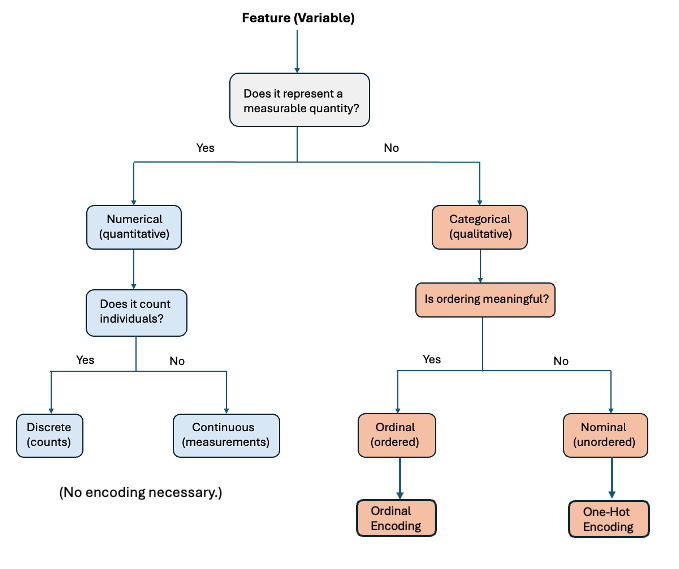